# 01 — ADME EDA (Part 1)

**Goal**: Understand the ADME dataset thoroughly before making any cleaning or modelling decisions.  
**Dataset**: `data/raw/ADME_public_set_3521.csv` — 3521 compounds, 6 log-transformed ADME endpoints.  
**Outputs**: Findings documented in Section 1.10; no data modified here.

In [14]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.eda import smiles_validity_report, missing_value_report
from src.features import rdkit_descriptors
from src.plotting import endpoint_distributions

SEED = 42
DATA_PATH = '../data/raw/ADME_public_set_3521.csv'

ENDPOINT_COLS = [
    'LOG HLM_CLint (mL/min/kg)',
    'LOG MDR1-MDCK ER (B-A/A-B)',
    'LOG SOLUBILITY PH 6.8 (ug/mL)',
    'LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)',
    'LOG PLASMA PROTEIN BINDING (RAT) (% unbound)',
    'LOG RLM_CLint (mL/min/kg)',
]

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1.1 — Load & Inspect

In [15]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
df.head()

Shape: (3521, 10)

Columns: ['Internal ID', 'Vendor ID', 'SMILES', 'CollectionName', 'LOG HLM_CLint (mL/min/kg)', 'LOG MDR1-MDCK ER (B-A/A-B)', 'LOG SOLUBILITY PH 6.8 (ug/mL)', 'LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)', 'LOG PLASMA PROTEIN BINDING (RAT) (% unbound)', 'LOG RLM_CLint (mL/min/kg)']

Dtypes:
Internal ID                                        object
Vendor ID                                          object
SMILES                                             object
CollectionName                                     object
LOG HLM_CLint (mL/min/kg)                         float64
LOG MDR1-MDCK ER (B-A/A-B)                        float64
LOG SOLUBILITY PH 6.8 (ug/mL)                     float64
LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)    float64
LOG PLASMA PROTEIN BINDING (RAT) (% unbound)      float64
LOG RLM_CLint (mL/min/kg)                         float64
dtype: object


,Internal ID,Vendor ID,SMILES,CollectionName,LOG HLM_CLint (mL/min/kg),LOG MDR1-MDCK ER (B-A/A-B),LOG SOLUBILITY PH 6.8 (ug/mL),LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),LOG PLASMA PROTEIN BINDING (RAT) (% unbound),LOG RLM_CLint (mL/min/kg)
0,Mol1,317714313,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,emolecules,0.6757,1.4932,0.0899,0.9912,0.5185,1.3922
1,Mol2,324056965,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,emolecules,0.6757,1.0408,0.5502,0.0997,0.2683,1.0279
2,Mol3,304005766,CN(c1ncc(F)cn1)[C@H]1CCCNC1,emolecules,0.6757,-0.3588,NaN,2.0000,2.0000,1.0279
3,Mol4,194963090,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,emolecules,0.6757,1.0267,1.6571,-1.1580,-1.4034,1.0279
4,Mol5,324059015,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,emolecules,0.9964,1.0106,NaN,1.0156,1.0923,1.6291


## 1.2 — SMILES Validity Report

Report only — no rows dropped here. Dropping is a cleaning decision made after EDA.

In [16]:
validity = smiles_validity_report(df, smiles_col='SMILES')
print(f"Valid SMILES  : {validity['valid_count']} ({validity['valid_count']/len(df)*100:.2f}%)")
print(f"Invalid SMILES: {validity['invalid_count']} ({validity['invalid_count']/len(df)*100:.2f}%)")
if validity['invalid_indices']:
    print(f"Invalid row indices: {validity['invalid_indices']}")
    print(df.loc[validity['invalid_indices'], ['Internal ID', 'SMILES']])
else:
    print('No invalid SMILES found.')

Valid SMILES  : 3521 (100.00%)
Invalid SMILES: 0 (0.00%)
No invalid SMILES found.


## 1.3 — Duplicate Check

In [17]:
from rdkit import Chem

# Duplicate raw SMILES strings
dup_raw = df['SMILES'].duplicated(keep=False)
print(f"Duplicate raw SMILES: {dup_raw.sum()} rows ({df['SMILES'].duplicated().sum()} extra copies)")

# Canonical SMILES duplicates (catches representation variants)
def to_canonical(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol is not None else None

df['canonical_smiles'] = df['SMILES'].apply(to_canonical)
dup_can = df['canonical_smiles'].duplicated(keep=False) & df['canonical_smiles'].notna()
n_dup_can = df['canonical_smiles'].duplicated().sum()
print(f"Duplicate canonical SMILES: {dup_can.sum()} rows ({n_dup_can} extra copies)")

if n_dup_can > 0:
    dup_df = df[dup_can].sort_values('canonical_smiles')
    # Check endpoint consistency among duplicates
    dup_ep_std = dup_df.groupby('canonical_smiles')[ENDPOINT_COLS].std()
    inconsistent = (dup_ep_std > 0).any(axis=1)
    print(f"Duplicates with inconsistent endpoint values: {inconsistent.sum()}")
    display(dup_df[['Internal ID', 'canonical_smiles'] + ENDPOINT_COLS].head(20))

Duplicate raw SMILES: 0 rows (0 extra copies)
Duplicate canonical SMILES: 0 rows (0 extra copies)


SMILES = string encoding of molecule
Canoncial SMILES = single, deterministic string generated via an algo (RDKit), always produces the same SMILES regardless of how molecule originally encoded.

## 1.4 — Missing Value Report

Missing values per endpoint:


,n_missing,pct_missing
LOG HLM_CLint (mL/min/kg),434,12.3300
LOG MDR1-MDCK ER (B-A/A-B),879,24.9600
LOG SOLUBILITY PH 6.8 (ug/mL),1348,38.2800
LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),3327,94.4900
LOG PLASMA PROTEIN BINDING (RAT) (% unbound),3353,95.2300
LOG RLM_CLint (mL/min/kg),467,13.2600


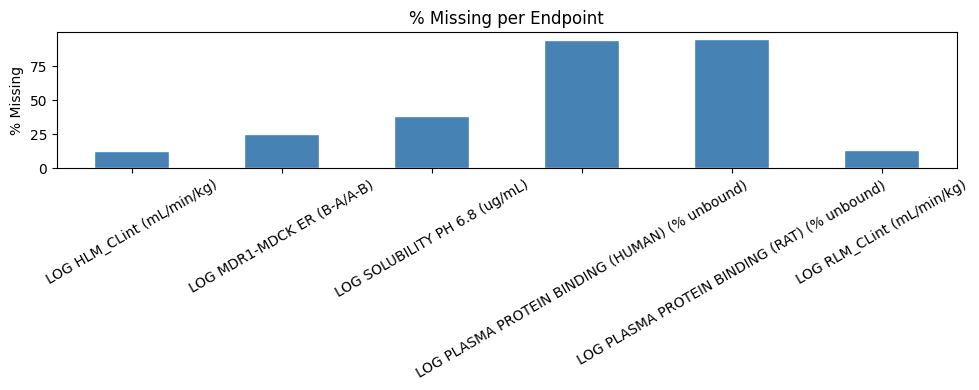

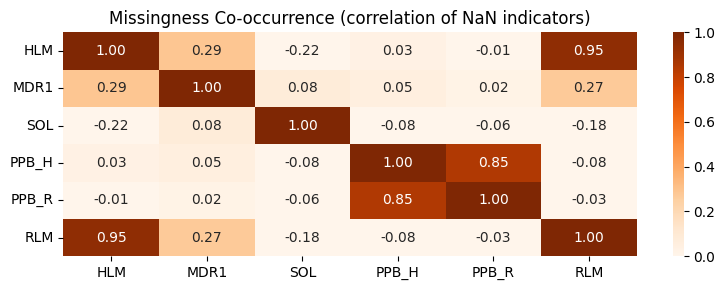

In [20]:
miss_report = missing_value_report(df, ENDPOINT_COLS)
print('Missing values per endpoint:')
display(miss_report)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
miss_report['pct_missing'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('% Missing per Endpoint')
ax.set_ylabel('% Missing')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Heatmap of missingness pattern
miss_matrix = df[ENDPOINT_COLS].isna().astype(int)
short_labels = ['HLM', 'MDR1', 'SOL', 'PPB_H', 'PPB_R', 'RLM']
miss_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(8, 3))
# Show a row sample — full heatmap on 3521 rows is unreadable
# Instead show missingness co-occurrence as correlation of missingness indicators
miss_corr = miss_matrix.corr()
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='Oranges', ax=ax, vmin=0, vmax=1)
ax.set_title('Missingness Co-occurrence (correlation of NaN indicators)')
plt.tight_layout()
plt.show()


HLM/RLM correlated in missingness -> Not all compounds tested so if a compound wasnt sent to the lab, its likely to be missing both not one or the other?

PPB_ H/R Same story, correlated as generally tested together?

## 1.5 — Summary Statistics

In [24]:
desc = df[ENDPOINT_COLS].describe().T

skew = df[ENDPOINT_COLS].apply(lambda x: stats.skew(x.dropna()))
kurt = df[ENDPOINT_COLS].apply(lambda x: stats.kurtosis(x.dropna()))

desc['skewness'] = skew
desc['kurtosis'] = kurt
desc.index = ['HLM', 'MDR1', 'SOL', 'PPB_H', 'PPB_R', 'RLM']

print('Summary statistics (all 6 endpoints):')
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

display(desc[['skewness', 'kurtosis']])

Summary statistics (all 6 endpoints):


,count,mean,std,min,25%,50%,75%,max
HLM,3087.0000,1.3200,0.6240,0.6757,0.6757,1.2053,1.8031,3.3727
MDR1,2642.0000,0.3978,0.6885,-1.1624,-0.1624,0.1533,0.9050,2.7251
SOL,2173.0000,1.2599,0.6834,-1.0000,1.1535,1.5428,1.6874,2.1793
PPB_H,194.0000,0.7657,0.8479,-1.5935,0.1681,0.8676,1.5020,2.0000
PPB_R,168.0000,0.7642,0.7990,-1.6383,0.2266,0.7764,1.3760,2.0000
RLM,3054.0000,2.2562,0.7504,1.0279,1.6883,2.3111,2.8353,3.9696


,skewness,kurtosis
HLM,0.6195,-0.6704
MDR1,0.7583,-0.5211
SOL,-1.6436,1.6604
PPB_H,-0.4798,-0.3784
PPB_R,-0.3902,-0.3364
RLM,-0.1074,-0.9859


SOL only column with | skew | > 1

## 1.6 — Outlier Detection

Flag compounds >3σ from the mean per endpoint. Report only — no rows removed.

In [21]:
outlier_summary = {}
outlier_indices = set()

for col in ENDPOINT_COLS:
    col_data = df[col].dropna()
    mu, sigma = col_data.mean(), col_data.std()
    mask = (df[col] - mu).abs() > 3 * sigma
    flagged = df.index[mask & df[col].notna()].tolist()
    outlier_summary[col] = len(flagged)
    outlier_indices.update(flagged)

print('Outlier counts per endpoint (>3σ):')
for k, v in outlier_summary.items():
    print(f"  {k}: {v}")
print(f"\nUnique compounds flagged in any endpoint: {len(outlier_indices)}")

if outlier_indices:
    print('\nFlagged rows (first 20):')
    display(df.loc[sorted(outlier_indices)[:20], ['Internal ID', 'SMILES'] + ENDPOINT_COLS])

Outlier counts per endpoint (>3σ):
  LOG HLM_CLint (mL/min/kg): 3
  LOG MDR1-MDCK ER (B-A/A-B): 1
  LOG SOLUBILITY PH 6.8 (ug/mL): 20
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): 0
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): 1
  LOG RLM_CLint (mL/min/kg): 0

Unique compounds flagged in any endpoint: 25

Flagged rows (first 20):


,Internal ID,SMILES,LOG HLM_CLint (mL/min/kg),LOG MDR1-MDCK ER (B-A/A-B),LOG SOLUBILITY PH 6.8 (ug/mL),LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),LOG PLASMA PROTEIN BINDING (RAT) (% unbound),LOG RLM_CLint (mL/min/kg)
97,Mol98,CCC1=C(C)CN(C(=O)NCCc2ccc(S(=O)(=O)NC(=O)N[C@H...,1.2843,1.8361,NaN,-1.1805,-1.6383,2.4846
303,Mol304,COc1ccccc1CNC(=O)C(C)N1CCCN(c2ccccc2C#N)CC1,3.3399,0.1781,1.6707,NaN,NaN,3.6044
909,Mol910,CC(C(=O)N1CCc2sccc2C1)N1CCCN(c2ccccc2C#N)CC1,3.3282,-0.0598,1.4082,NaN,NaN,3.6266
1914,Mol1915,c1nn(C2CCOCC2)cc1Nc1ncc2nnn(-c3ccc4cn[nH]c4c3)...,1.9858,2.7251,NaN,NaN,NaN,2.8839
2787,Mol2788,Cc1cc(C)nc(SCC(=O)N2c3ccccc3C(C)(c3ccccc3)CC2(...,3.3727,NaN,NaN,NaN,NaN,3.4953
3067,Mol3068,COc1ccc([C@H]2c3[nH]c4ccc(Cl)cc4c3CCN2C(=O)Oc2...,NaN,-0.3646,-1.0000,1.5129,1.7546,NaN
3135,Mol3136,Fc1cccc(Cn2nnc(-c3ccccc3)n2)c1F,NaN,-0.4464,-1.0000,NaN,NaN,NaN
3158,Mol3159,COc1ccc2nc(C(=O)Nc3cnc4c(cnn4C(C)C)c3)ccc2c1,NaN,-0.3336,-0.8239,NaN,NaN,NaN
3190,Mol3191,Cc1cc(C)c(-c2csc(NC(=O)Cn3cnnn3)n2)c(C)c1,NaN,0.8859,-0.9208,NaN,NaN,NaN
3199,Mol3200,Cc1nc(Nc2ccc(F)cc2)nc2c1ncn2-c1ccc(F)cc1,NaN,-0.4113,-0.8539,NaN,NaN,NaN


Consider IQR outlier detection, better for skewed data

## 1.7 — Endpoint Distributions

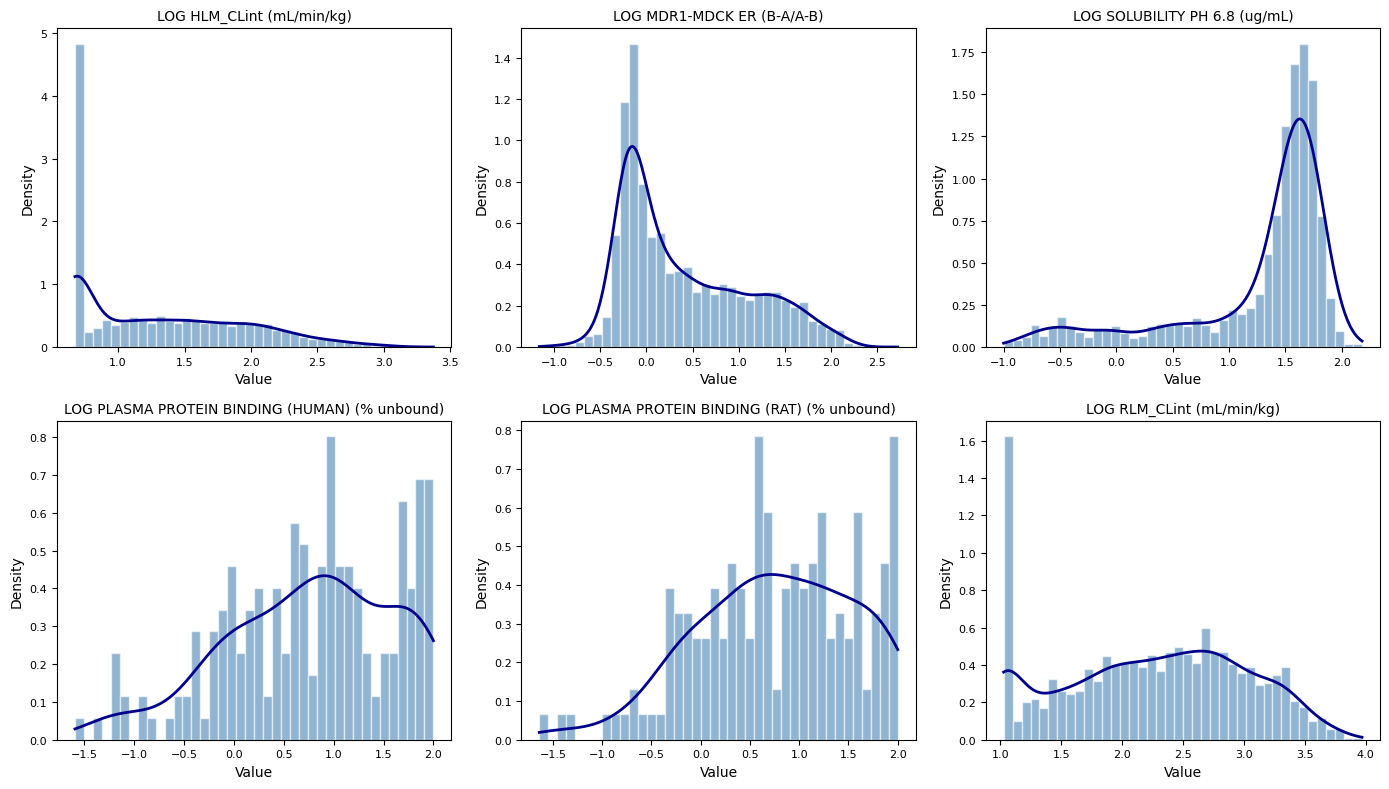

In [22]:
fig = endpoint_distributions(df, ENDPOINT_COLS)
plt.show()

**Distribution notes**:
- HLM_CLint: +ve skew, tail points right
- MDR1-MDCK ER: +ve skew
- SOLUBILITY: -ve skew
- PPB HUMAN: mild -ve skew
- PPB RAT: mild -ve skew
- RLM_CLint: No strong peak

## 1.8 — Endpoint Correlations

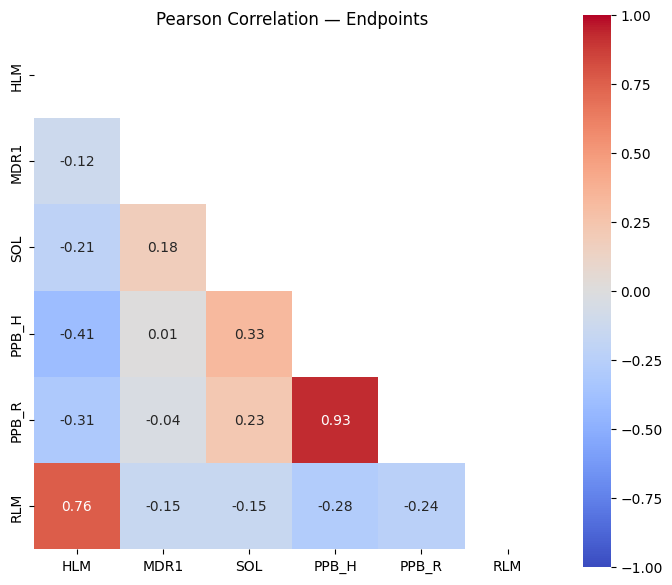

In [9]:
corr = df[ENDPOINT_COLS].corr(method='pearson')
corr.index = corr.columns = ['HLM', 'MDR1', 'SOL', 'PPB_H', 'PPB_R', 'RLM']

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax, square=True
)
ax.set_title('Pearson Correlation — Endpoints')
plt.tight_layout()
plt.show()

## 1.9 — Chemical Space Overview

In [23]:
# Pre-validate SMILES before featurising — rdkit_descriptors raises on invalid input
assert validity["invalid_count"] == 0, f"Fix {validity['invalid_count']} invalid SMILES before featurising"

# Compute RDKit 2D descriptors (uses only valid SMILES)
desc_df = rdkit_descriptors(df['SMILES'].tolist())
desc_df.index = df.index
print('Descriptor shape:', desc_df.shape)
display(desc_df.describe())

Descriptor shape: (3521, 6)


,MW,LogP,TPSA,HBD,HBA,RotBonds
count,3521.0000,3521.0000,3521.0000,3521.0000,3521.0000,3521.0000
mean,323.8563,2.8098,63.9421,1.0148,4.5180,4.0432
std,75.9329,1.1720,21.6192,0.8290,1.5968,1.8797
min,150.1450,-1.9800,3.2400,0.0000,1.0000,0.0000
25%,268.3200,2.0532,49.3300,1.0000,3.0000,3.0000
50%,313.7920,2.7828,60.1500,1.0000,4.0000,4.0000
75%,364.4890,3.5326,74.4400,1.0000,5.0000,5.0000
max,1097.3980,9.0141,258.5200,8.0000,16.0000,35.0000


MW = Molecular weight
LogP = Lipophilicity
TPSA = Topological polar surface area - absorption/permeability
HBD = H-bond donors
HBA = H-bond acceptros
RotBonds = Rotatable bonds - flexibility

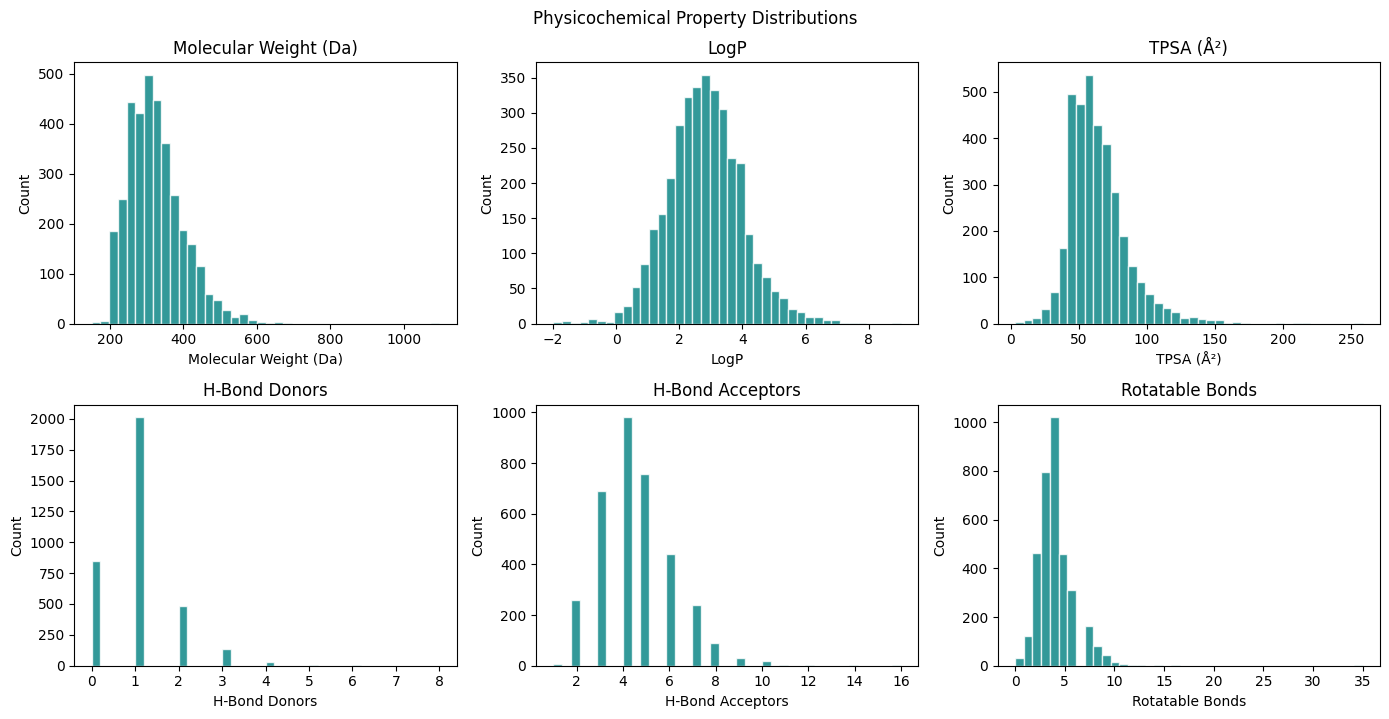

In [12]:
# Histograms of physicochemical properties
prop_labels = {
    'MW': 'Molecular Weight (Da)',
    'LogP': 'LogP',
    'TPSA': 'TPSA (Å²)',
    'HBD': 'H-Bond Donors',
    'HBA': 'H-Bond Acceptors',
    'RotBonds': 'Rotatable Bonds',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, label) in zip(axes.flatten(), prop_labels.items()):
    data = desc_df[col].dropna()
    ax.hist(data, bins=40, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.suptitle('Physicochemical Property Distributions', y=1.02)
plt.show()

In [13]:
# Lipinski Ro5 violations (informational only)
lip_violations = (
    (desc_df['MW'] > 500).astype(int) +
    (desc_df['LogP'] > 5).astype(int) +
    (desc_df['HBD'] > 5).astype(int) +
    (desc_df['HBA'] > 10).astype(int)
)

print('Lipinski Ro5 violations per compound:')
print(lip_violations.value_counts().sort_index())
print(f"\nCompounds with >=2 violations (Ro5 fails): {(lip_violations >= 2).sum()} "
      f"({(lip_violations >= 2).mean()*100:.1f}%)")

Lipinski Ro5 violations per compound:
0    3332
1     148
2      39
3       1
4       1
Name: count, dtype: int64

Compounds with >=2 violations (Ro5 fails): 41 (1.2%)


3332 compounds break 0 rules, 148 break 1 rule etc

## 1.10 — EDA Conclusions

> **No decisions made here.** Findings are documented; cleaning strategy (SYNC-002) decided post-EDA review.

### Invalid SMILES
- **Finding**: 0 invalid SMILES out of 3521 (100% valid). No action required.

### Duplicates
- **Finding**: 0 duplicate raw SMILES; 0 duplicate canonical SMILES. Dataset is clean on this front.

### Missingness
- **Finding**: Missingness varies dramatically by endpoint:
  - HLM: 434 missing (12.3%), RLM: 467 missing (13.3%) — manageable
  - MDR1: 879 missing (25.0%), SOL: 1348 missing (38.3%) — substantial
  - PPB_HUMAN: 3327 missing (94.5%), PPB_RAT: 3353 missing (95.2%) — near-complete missingness
- **Cleaning strategy to decide (SYNC-002)**: PPB endpoints are nearly empty — likely not useful for modelling. Per-endpoint filtering (train each model on rows with non-missing values for that endpoint) is strongly preferred over complete-cases (which would leave only ~5% of data). Decision after supervisor review.

### Endpoint Distributions & Outliers
- **Skewness**: SOLUBILITY is left-skewed (skew=-1.64); HLM and MDR1 are mildly right-skewed (~0.6–0.8); RLM, PPB endpoints near-symmetric.
- **Outliers (>3σ)**: SOLUBILITY has 20 flagged outliers — largest concern. HLM: 3, MDR1: 1, PPB_RAT: 1. ~25 unique compounds flagged across all endpoints.
- **Endpoints to watch**: SOLUBILITY (high skew + most outliers + high missingness).

### Chemical Space
- **Drug-likeness**: 94.7% of compounds have 0 Lipinski Ro5 violations.
- **Violations**: 148 compounds have 1 violation, 41 have ≥2 (Ro5 fails).

### Next Step
Review findings with supervisor → confirm SYNC-002 cleaning strategy (per-endpoint recommended given PPB missingness) → proceed to Part 2 (baseline models).